---
format: 
    html:
        embed-resources: true
---


# Supervised Learning: Analysis of Debts (USD) on Number of Subway Trips Made On Time

## Data Preprocessing

### Regression and Multi-class Classification Decision Tree Data Processing section:

In [2]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import tree
from IPython.display import Image
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [3]:
#load merged debts financial csv file dataset for eda
debts_dataset = pd.read_csv("../../data/processed-data/Debts_reliability_binary.csv")
#convert csv file into a dataframe
debts_df = pd.DataFrame(debts_dataset)
#print first few rows of dataframe
print(debts_df.head())
#print columns of dataframe
print(debts_df.columns)

   Unnamed: 0 Statements of Revenue, Expenses and Changes in Net Position  \
0           0                        Revenue from transportation            
1           1                           Total operating revenues            
2           2                            Transportation services            
3           3                           Other operating expenses            
4           4   Total operating expenses, excluding depreciation            

         Date  Net Position Amounts (USD)  ontime_trip_count  trip_count  \
0  2023-06-30                      376357               2925        3297   
1  2023-06-30                      452973               2925        3297   
2  2023-06-30                      822671               2925        3297   
3  2023-06-30                      968312               2925        3297   
4  2023-06-30                     1790983               2925        3297   

          Time  Pre and Post 2021  Pre and Post 2021 Binary  
0  04:00:00+00    

In [4]:
#drop unneeded columns
debts_df_drop = debts_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)

In [15]:
#code re-used from DSAN 5000 Lab 5.3
#set variable Y to the "target" collumn of the dataframe
Y_debt = debts_df_drop['ontime_trip_count']

#set variable X to the rest of the columns in the dataframe
X_debt = debts_df_drop[['Debt (USD)','trip_count','Pre and Post 2021 Binary']]

#print shape of Y and X to check number of rows and cols
print(Y_debt.shape)
print(X_debt.shape)

(5,)
(5, 3)


### Binary Classifiction - Neural Network: Data Processing Section

In [14]:
#import libraries
#attempted to apply neaural network model onto the debt dataset as binary classification but had trouble installing the tensorflow library  
#from tensorflow import keras
#from tensorflow.keras import layers

#get features and target feature from debts dataset
#binary_Y = debts_df_drop['ontime_trip_count'].values
#binary_X = debts_df_drop[['Debt (USD)','trip_count','Pre and Post 2021 Binary']].values

## Training and Testing Strategy

In [16]:
#code re-used from DSAN 5000 Lab 5.3
#partition debt data
from sklearn.model_selection import train_test_split

#partition dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(X_debt,Y_debt, test_size=0.2, random_state=42)

In [17]:
#code re-used from DSAN 5000 Lab 5.3
#print type and shape as check point: x_train, x_test, y_train, y_test
print(type(x_train), x_train.shape) #print type and shape of x_train set
print(type(x_test), x_test.shape) #print type and shape of x_test set
print(type(y_train), y_train.shape) #print type and shape of y_train set
print(type(y_test), y_test.shape) #print type and shape of y_test set


<class 'pandas.core.frame.DataFrame'> (4, 3)
<class 'pandas.core.frame.DataFrame'> (1, 3)
<class 'pandas.core.series.Series'> (4,)
<class 'pandas.core.series.Series'> (1,)


## Model Selection:

### Multi-class Classification Section:

In [18]:
#code re-used from DSAN 5000 Lab 5.3
#train sklearn decision tree model on the x-train, y_train of the net position dataset
from sklearn import tree #import tree library
model = tree.DecisionTreeClassifier() #set classifier for decision tree
debt_tree_model = model.fit(x_train, y_train) #fit decision tree model on x_train and y_train sets

In [19]:
#code re-used from DSAN 5000 Lab 5.3
#use tree model to make predictions for the training and test set
debt_y_train = debt_tree_model.predict(x_train) #make predictions for training set
debt_y_test = debt_tree_model.predict(x_test) #make predictions for test set

print(debt_y_train) #print predictions for training set
print(debt_y_test) #print predictions for test set

[1914 2329 2925 1825]
[1825]


### Regression section

In [34]:
#import skearn libraries and tree modules
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

#create object that is decision tree regressor
regressor = DecisionTreeRegressor()

#train the model on the decision tree regressor
reg_tree_model = regressor.fit(x_train, y_train)

#make prediction on the test set
reg_y_pred = reg_tree_model.predict(x_test)

### Binary Classification Section

In [37]:
#import logisticRegression library
from sklearn.linear_model import LogisticRegression

#create logistic regression model
logistic = LogisticRegression()

#fit logistic regression model on the training data
logistic_model = logistic.fit(x_train, y_train)

#make prediction on the test set
log_y_pred = logistic_model.predict(x_test)

## Model Evaluation Metrics:

### Multi-Class Classification:

In [22]:
#code re-used from DSAN 5000 Lab 5.3
#function def confusion_plot(y_data,y_pred) generates a confusion matrix plot and prints information from function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #import sklearn libraries to create confusion matrix

def confusion_plot(y_data, y_pred):
    labels = np.unique(np.concatenate((Y_debt, y_pred))) #unique labels from target data and y_pred to be used for confusion matrix
    confusion_mat = confusion_matrix(y_data, y_pred, labels = labels) #create confusion matrix
    confusion_plot = ConfusionMatrixDisplay(confusion_matrix =  confusion_mat, display_labels = labels) #generate confusion matrix plot

    accuracy = accuracy_score(y_data, y_pred) #calculate accuracy score of matrix plot

    recall = recall_score(y_data, y_pred, average='macro') #calculate recall score, use average ='macro' for multi-class classification
    precision = precision_score(y_data, y_pred, average='macro') #calculated precision score, use average ='macro' for multi-class classification
    
    print("ACCURACY: ", accuracy) #print accuracy score
    print("RECALL: ", recall) #print recall score
    print("PRECISION: ", precision) #print precision score
    print(confusion_mat.shape) #print shape of confusion matrix
    print(confusion_mat) #print out the confusion matrix with labels

    confusion_plot.plot() #plot the confusion matrix
    plt.show() #show plot

------TRAINING------
ACCURACY:  1.0
RECALL:  1.0
PRECISION:  1.0
(5, 5)
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]


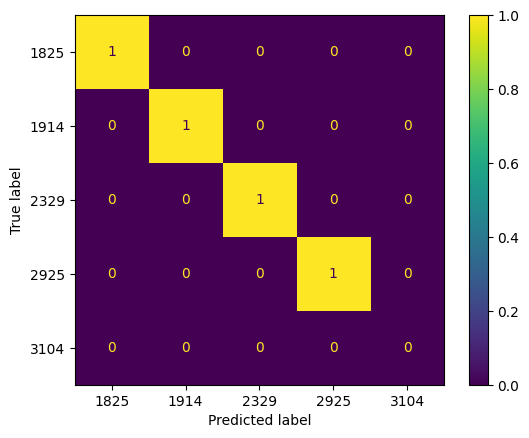

------TEST------
ACCURACY:  0.0
RECALL:  0.0
PRECISION:  0.0
(5, 5)
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]]


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


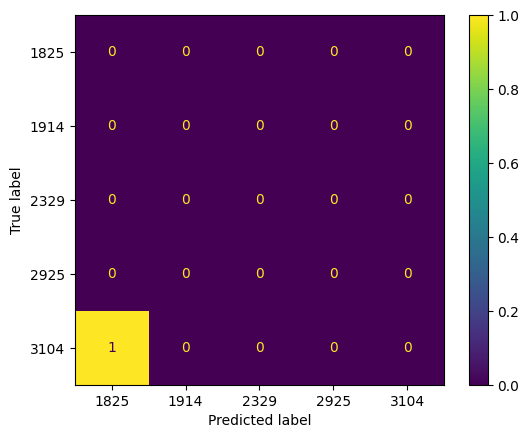

In [23]:
#code re-used from DSAN 5000 Lab 5.3
print("------TRAINING------")
confusion_plot(y_train,debt_y_train)
print("------TEST------")
confusion_plot(y_test,debt_y_test)


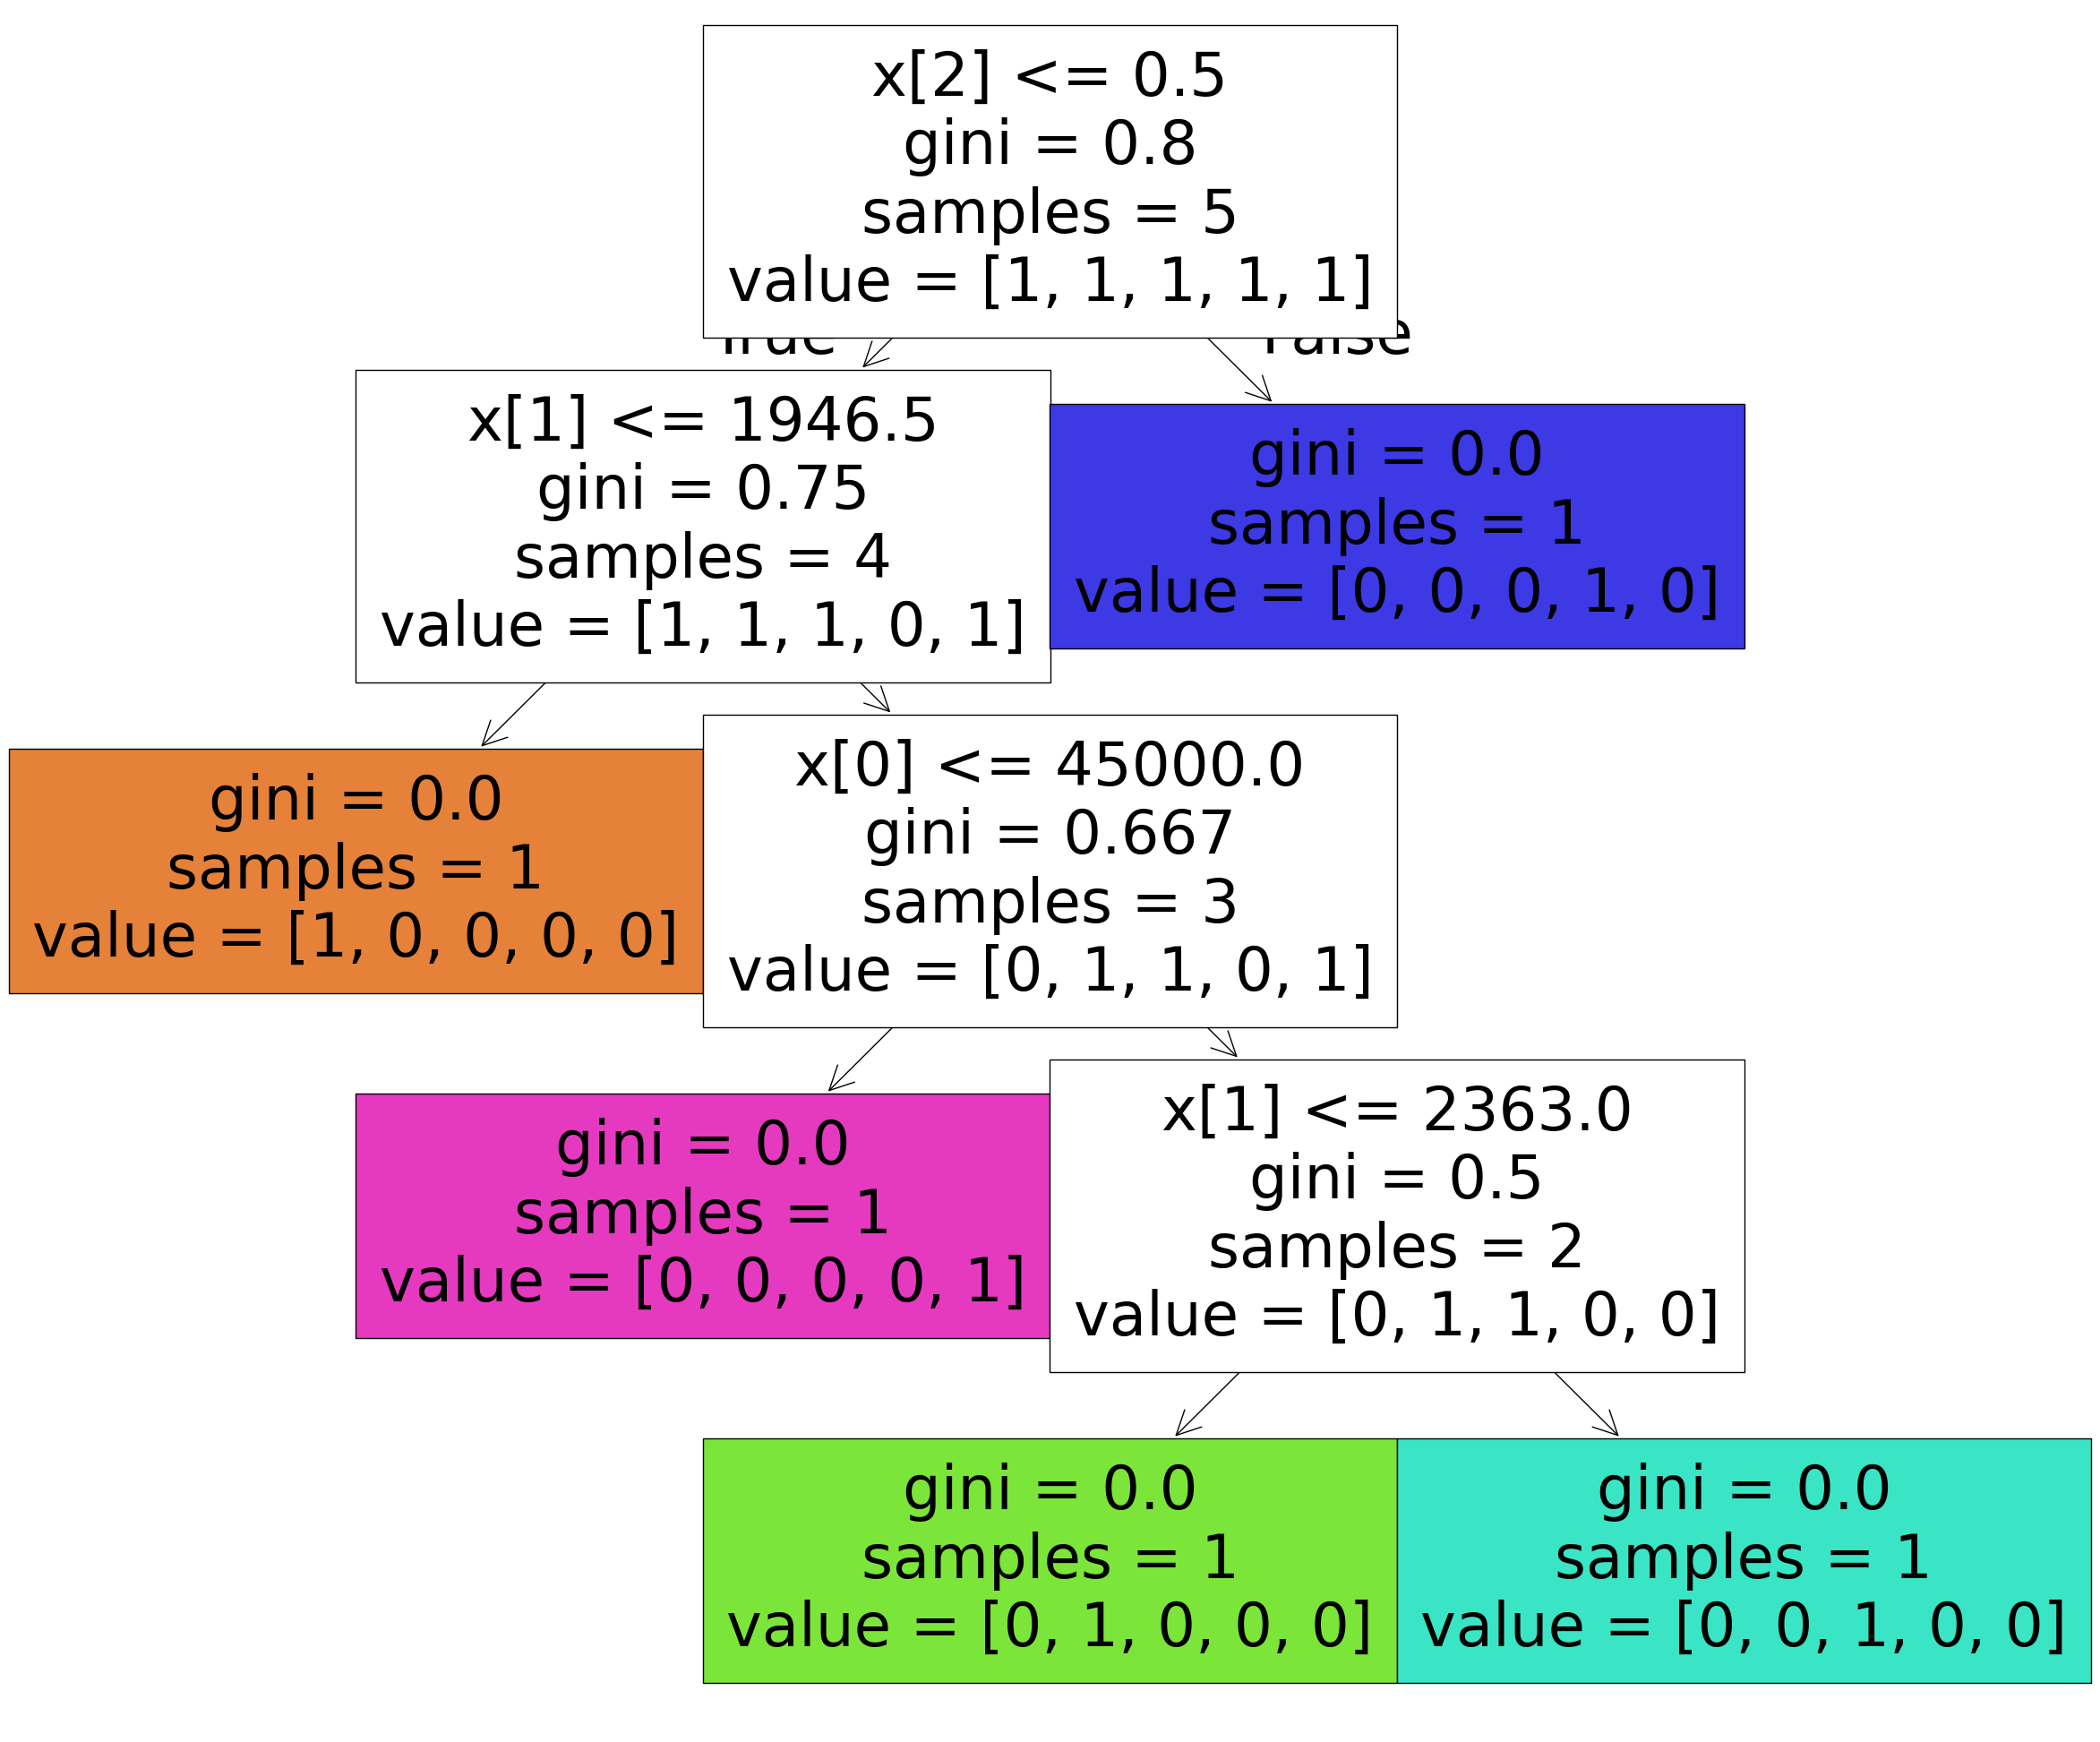

In [33]:
#code re-used from DSAN 5000 Lab 5.3
#function def plot_tree(model, X,Y) visualized the decision tree
#import sklearn libraries to make decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

def plot_tree(model, X,Y):
    model = DecisionTreeClassifier() #use classifier to create classification decision tree
    model.fit(X,Y) #fit data into decision tree classifier

    plt.figure(figsize=(30,25)) #set figure size for decision tree plot
    tree.plot_tree(model, filled=True) #plot the decision tree of data
    plt.show() #show decision tree plot


plot_tree(model, X_debt,Y_debt) #call plot_tree function


In [26]:
##code re-used from DSAN 5000 Lab 5.3
#loop over possible hyper-parameter values
debt_test_results=[] #initialize empty list to store test set results
debt_train_results=[] #initialize empty list to store train set results

for num_layer in range(1,20): #iterage over "max-depth"
    model = tree.DecisionTreeClassifier(max_depth=num_layer) #adjust max_depth hyper-parameter in the decision tree classifier
    debt_model = model.fit(x_train, y_train) #fit model on the x_train and y_train set

    debt_yp_train=debt_model.predict(x_train) #get model predictions on the x_train set
    debt_yp_test=debt_model.predict(x_test) #get model predictions on the x_test set

    debt_test_results.append([num_layer,accuracy_score(y_test, debt_yp_test),recall_score(y_test, debt_yp_test, average='macro')]) #append results of test set
    debt_train_results.append([num_layer,accuracy_score(y_train, debt_yp_train),recall_score(y_train, debt_yp_train, average='macro')]) #append results of training set


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

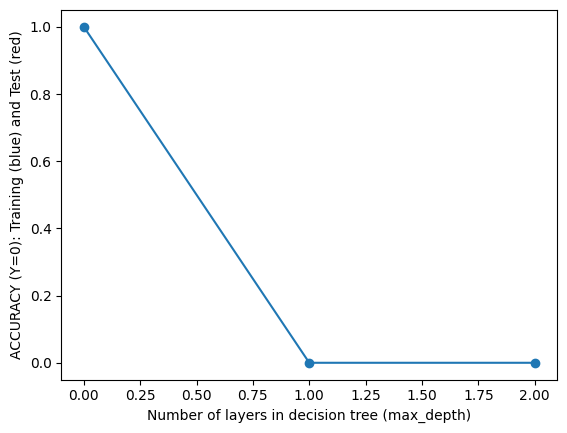

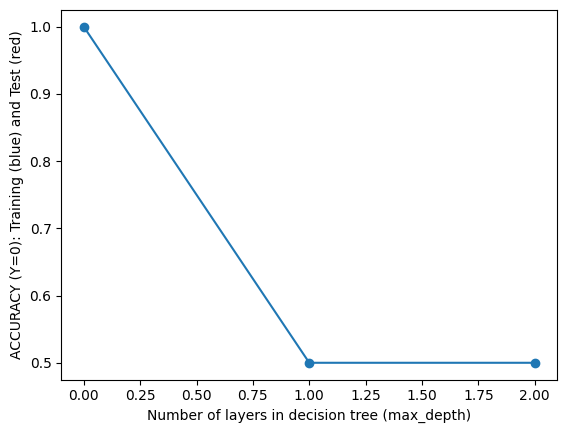

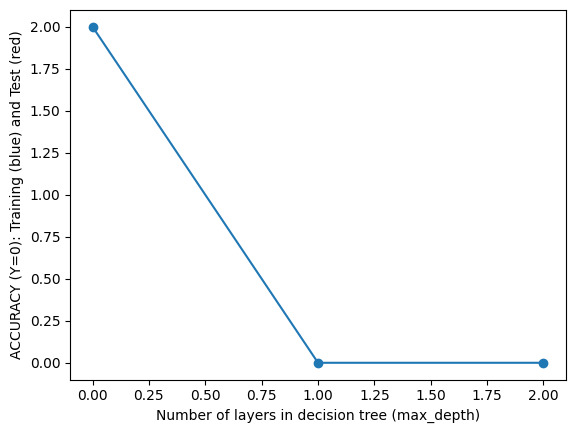

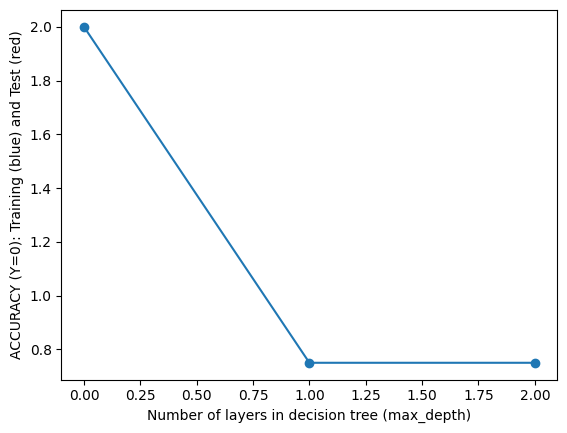

In [27]:
##code re-used from DSAN 5000 Lab 5.3
#create line plot for number of layers of decision tree model on test set
plt.plot(debt_test_results[0], marker='o') #plot the accuracy score value of the training and test set, extracted from the test_results and the train_results lists
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('ACCURACY (Y=0): Training (blue) and Test (red)') #set y-axis label
plt.show() #show plot

#create line plot for number of layers of decision tree model on training set
plt.plot(debt_train_results[0], marker='o') #plot the accuracy score value of the training and test set, extracted from the test_results and the train_results lists
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('ACCURACY (Y=0): Training (blue) and Test (red)') #set y-axis label
plt.show() #show plot

#create line plot for accuracy score of decision tree model on test set
plt.plot(debt_test_results[1], marker='o') #plot the accuracy score value of the training and test set, extracted from the test_results and the train_results lists
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('ACCURACY (Y=0): Training (blue) and Test (red)') #set y-axis label
plt.show() #show plot

#create line plot for accuracy score of decision tree model on training set
plt.plot(debt_train_results[1], marker='o') #plot the accuracy score value of the training and test set, extracted from the test_results and the train_results lists
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('ACCURACY (Y=0): Training (blue) and Test (red)') #set y-axis label
plt.show() #show plot

In [29]:
##code re-used from DSAN 5000 Lab 5.3
#re-train the decision tree using the optimal hyper-parameter obtained from the line plots created above. Use max-depth = 2 as test to see if the tree model performance improves

model = tree.DecisionTreeClassifier(max_depth=2) #based on the three plots above, set the max_depth = 2
debt_model = model.fit(x_train, y_train) #fit model onto x_train and y_train set

debt_yp_train=debt_model.predict(x_train) #make predictions on x_train set
debt_yp_test=debt_model.predict(x_test) #make predictions on x_test set


------TRAINING------
ACCURACY:  0.75
RECALL:  0.75
PRECISION:  0.625
(5, 5)
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


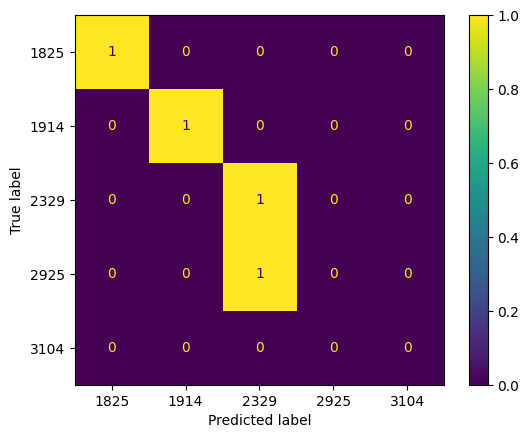

------TEST------
ACCURACY:  0.0
RECALL:  0.0
PRECISION:  0.0
(5, 5)
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]]


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


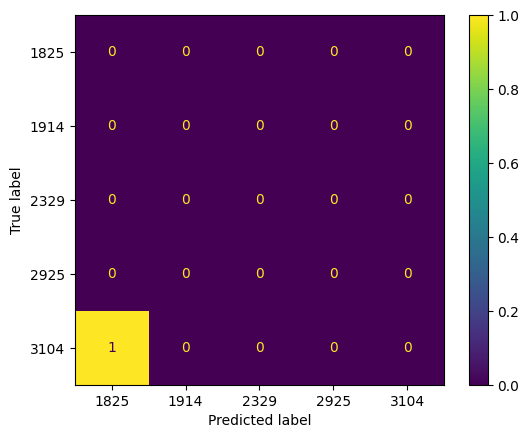

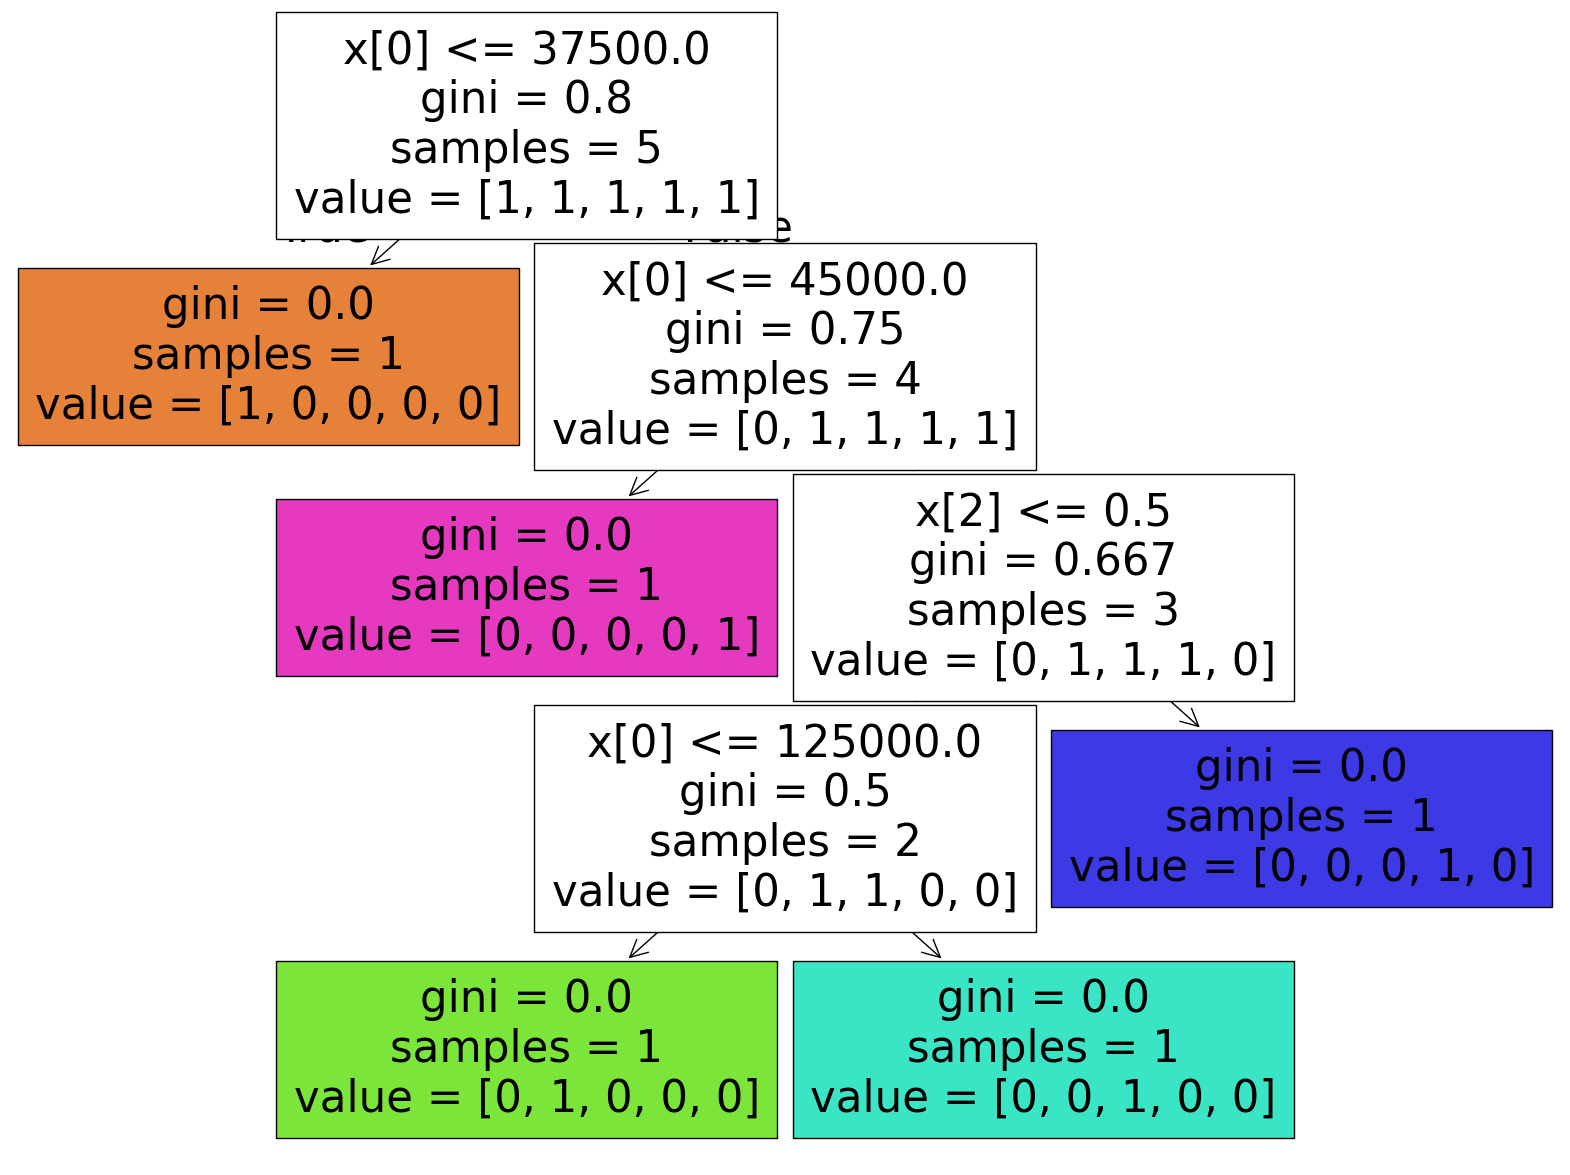

In [31]:
##code re-used from DSAN 5000 Lab 5.3
#after updating the max depth of tree model to 2 to hypertune the tree model, re-train the net position dataset to see if the hypertuning improved the tree model performance
print("------TRAINING------")
confusion_plot(y_train,debt_yp_train)
print("------TEST------")
confusion_plot(y_test,debt_yp_test)

plot_tree(debt_model,X_debt, Y_debt)


### Regression section:

In [35]:
#evaluate regression tree model
mse = mean_squared_error(y_test, reg_y_pred)
print("Mean Squared Error: ", mse)

Mean Squared Error:  32041.0


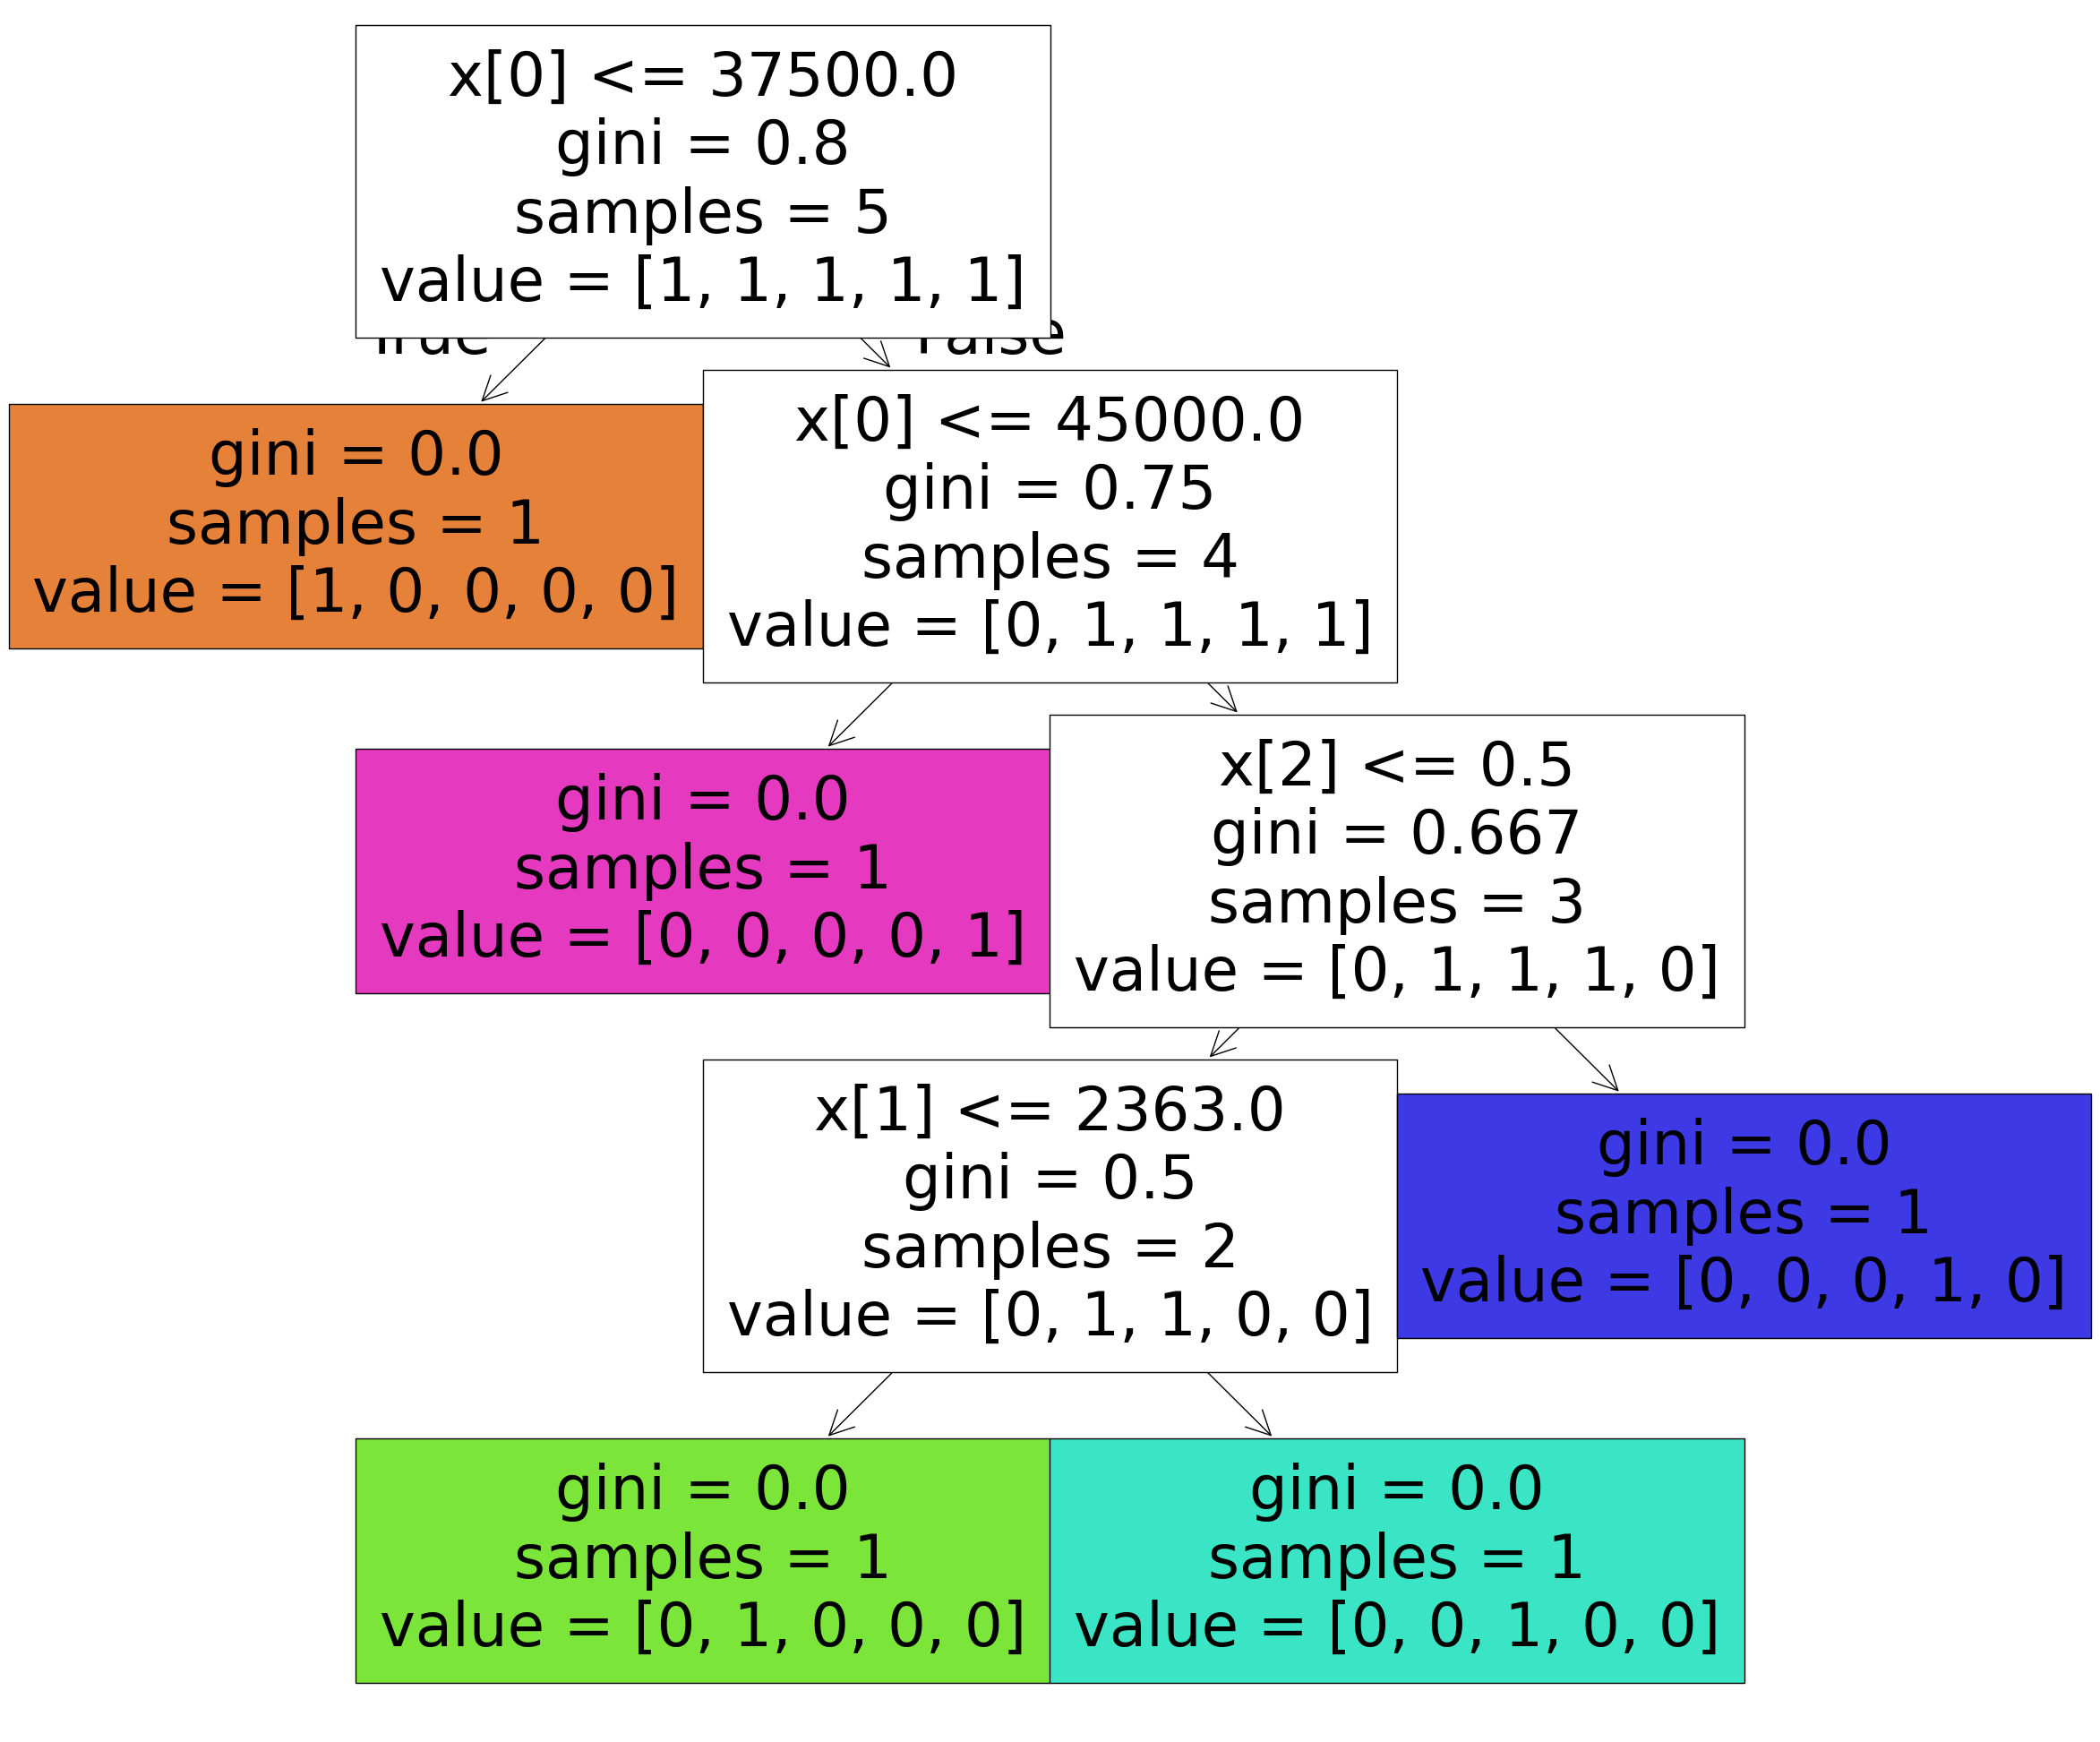

In [36]:
#visualize using regression tree model
plot_tree(reg_tree_model,X_debt, Y_debt)

### Binary Classification section:

In [39]:
#get accuracy score of logistic regression model fit on the debts dataset
logistic_accuracy = accuracy_score(y_test, log_y_pred )
print("Accuracy:", logistic_accuracy)

Accuracy: 0.0


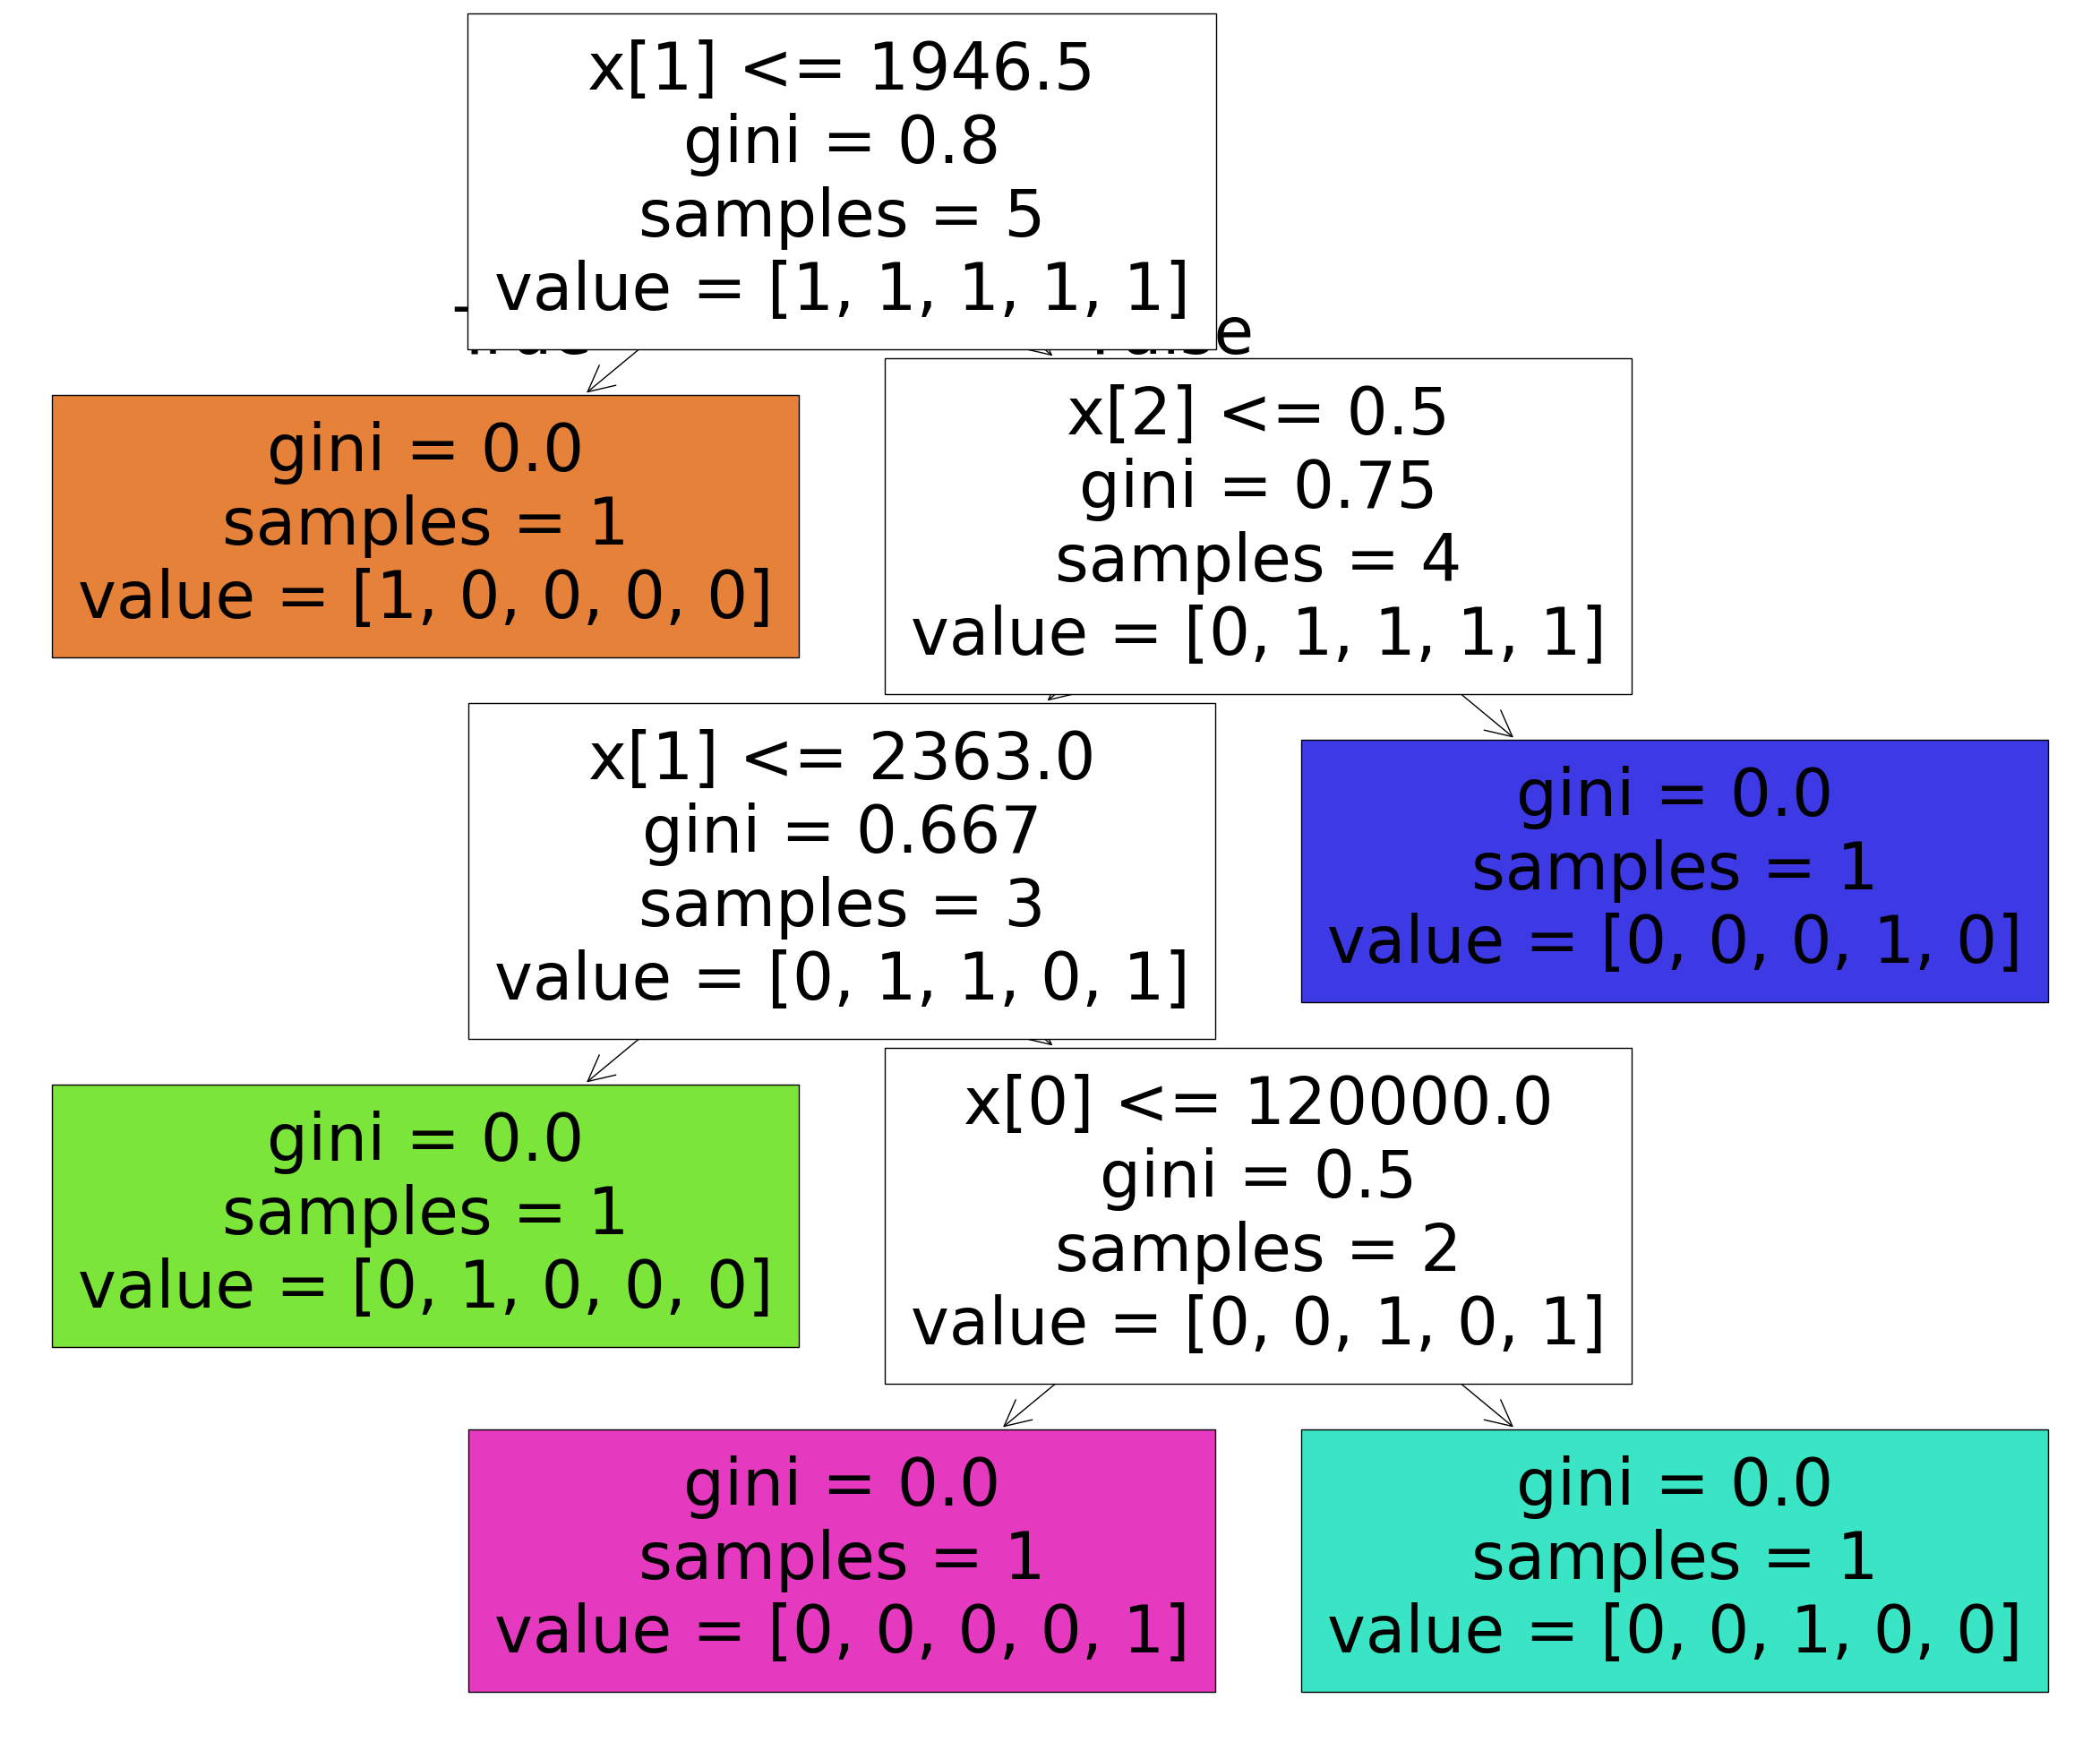

In [40]:
#visualize using regression tree model
plot_tree(logistic_model,X_debt, Y_debt)